# Gradient Descent Variants and Momentum

## Introduction
We will explore different optimization algorithms used in training neural networks. 

Specifically, we will look at:
1.  **Batch Gradient Descent**
2.  **Stochastic Gradient Descent (SGD)**
3.  **Mini-batch Gradient Descent**
4.  **Gradient Descent with Momentum**

We will use a simple **Linear Regression** problem with synthetic data to visualize how these algorithms update the model parameters (weights and bias) and converge to the minimum loss.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

%matplotlib inline

## 1. Data Generation

We will generate synthetic data for a simple linear relationship:  
$$ y = 2x + 3 + \text{noise} $$

Here, the true weight $w = 2$ and true bias $b = 3$.

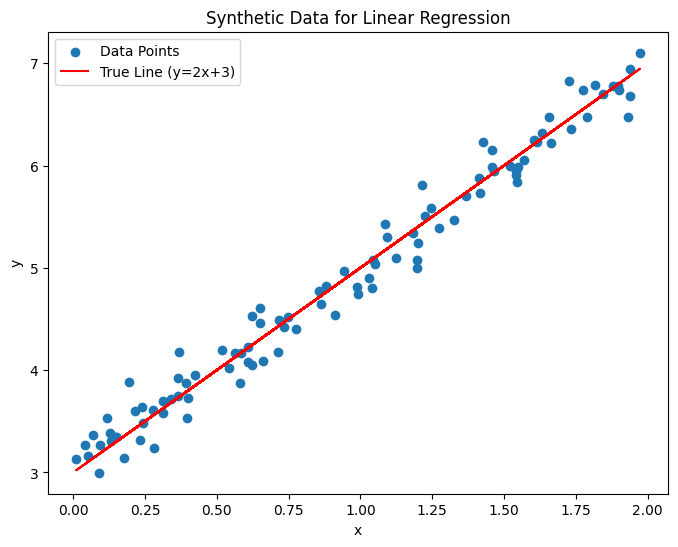

In [2]:
# Generate synthetic data
X = np.random.rand(100, 1) * 2  # 100 data points between 0 and 2
y = 2 * X + 3 + np.random.randn(100, 1) * 0.2  # Add some noise

# Convert to PyTorch tensors
X_tensor = torch.from_numpy(X).float()
y_tensor = torch.from_numpy(y).float()

# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(X, y, label='Data Points')
plt.plot(X, 2 * X + 3, color='red', label='True Line (y=2x+3)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Synthetic Data for Linear Regression')
plt.legend()
plt.show()

## 2. Helper Functions

We define the model (Linear Regression) and the Loss Function (Mean Squared Error).

In [3]:
def model(x, w, b):
    return w * x + b

def mse_loss(y_pred, y_true):
    return torch.mean((y_pred - y_true) ** 2)

# Function to compute gradients manually (for educational purposes)
def compute_gradients(x, y_true, w, b):
    # Forward pass
    y_pred = model(x, w, b)
    
    # Gradients for MSE: 
    # dL/dw = 2/N * sum((y_pred - y) * x)
    # dL/db = 2/N * sum(y_pred - y)
    N = y_true.shape[0]
    error = y_pred - y_true
    
    dw = (2/N) * torch.sum(error * x)
    db = (2/N) * torch.sum(error)
    
    return dw, db, mse_loss(y_pred, y_true)

## 3. Batch Gradient Descent

**Concept**: Compute the gradient of the cost function with respect to the parameters for the **entire training dataset**.

- **Pros**: Stable convergence, computationally efficient (vectorization).
- **Cons**: Slow for very large datasets (requires loading all data), can get stuck in local minima (though not an issue for convex problems like Linear Regression).

In [4]:
# Initialization
w_batch = torch.tensor(0.0, requires_grad=False)
b_batch = torch.tensor(0.0, requires_grad=False)

lr = 0.1
epochs = 50

batch_history = {'w': [], 'b': [], 'loss': []}

print("Training Batch Gradient Descent...")
for epoch in range(epochs):
    # Compute gradients using ALL data
    dw, db, loss = compute_gradients(X_tensor, y_tensor, w_batch, b_batch)
    
    # Update parameters
    w_batch = w_batch - lr * dw
    b_batch = b_batch - lr * db
    
    # Store history
    batch_history['w'].append(w_batch.item())
    batch_history['b'].append(b_batch.item())
    batch_history['loss'].append(loss.item())
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

print(f"Final Parameters: w = {w_batch.item():.4f}, b = {b_batch.item():.4f}")

Training Batch Gradient Descent...
Epoch 0: Loss = 25.1897
Epoch 10: Loss = 0.1159
Epoch 20: Loss = 0.0739
Epoch 30: Loss = 0.0531
Epoch 40: Loss = 0.0427
Final Parameters: w = 2.0703, b = 2.9113


## 4. Stochastic Gradient Descent (SGD)

**Concept**: Compute the gradient and update parameters for **each training example** one by one.

- **Pros**: Faster updates, can escape local minima due to noise.
- **Cons**: High variance in updates (noisy convergence), computationally expensive (cannot fully utilize vectorization).

In [5]:
# Initialization
w_sgd = torch.tensor(0.0, requires_grad=False)
b_sgd = torch.tensor(0.0, requires_grad=False)

lr_sgd = 0.1
epochs_sgd = 5 # Fewer epochs as we update N times per epoch

sgd_history = {'w': [], 'b': [], 'loss': []}

print("Training SGD...")
for epoch in range(epochs_sgd):
    # Shuffle data
    indices = torch.randperm(X_tensor.size(0))
    X_shuffled = X_tensor[indices]
    y_shuffled = y_tensor[indices]
    
    for i in range(X_tensor.size(0)):
        xi = X_shuffled[i:i+1]
        yi = y_shuffled[i:i+1]
        
        # Compute gradient for SINGLE example
        dw, db, loss = compute_gradients(xi, yi, w_sgd, b_sgd)
        
        # Update parameters
        w_sgd = w_sgd - lr_sgd * dw
        b_sgd = b_sgd - lr_sgd * db
        
        sgd_history['w'].append(w_sgd.item())
        sgd_history['b'].append(b_sgd.item())
        sgd_history['loss'].append(loss.item())

print(f"Final Parameters: w = {w_sgd.item():.4f}, b = {b_sgd.item():.4f}")

Training SGD...
Final Parameters: w = 1.8790, b = 3.0522


## 5. Mini-batch Gradient Descent

**Concept**: Compute the gradient for a **small batch** of training examples (e.g., 32, 64).

- **Pros**: Best of both worlds. Reduces variance compared to SGD, efficient use of vectorization.
- **Cons**: Need to tune batch size.

In [6]:
# Initialization
w_mini = torch.tensor(0.0, requires_grad=False)
b_mini = torch.tensor(0.0, requires_grad=False)

lr_mini = 0.1
epochs_mini = 20
batch_size = 16

mini_history = {'w': [], 'b': [], 'loss': []}

print("Training Mini-batch GD...")
for epoch in range(epochs_mini):
    indices = torch.randperm(X_tensor.size(0))
    X_shuffled = X_tensor[indices]
    y_shuffled = y_tensor[indices]
    
    for i in range(0, X_tensor.size(0), batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        dw, db, loss = compute_gradients(X_batch, y_batch, w_mini, b_mini)
        
        w_mini = w_mini - lr_mini * dw
        b_mini = b_mini - lr_mini * db
        
        mini_history['w'].append(w_mini.item())
        mini_history['b'].append(b_mini.item())
        mini_history['loss'].append(loss.item())

print(f"Final Parameters: w = {w_mini.item():.4f}, b = {b_mini.item():.4f}")

Training Mini-batch GD...
Final Parameters: w = 1.9586, b = 3.0292


## 6. Gradient Descent with Momentum

**Concept**: Accumulate an exponential moving average of past gradients to smooth out updates. It helps accelerate SGD in the relevant direction and dampens oscillations.

$$ v_t = \beta v_{t-1} + (1 - \beta) \nabla J(\theta) $$
$$ \theta = \theta - \alpha v_t $$

*(Note: Implementations vary slightly. PyTorch uses $v_t = \mu v_{t-1} + g_t$ and \theta = \theta - \text{lr} * v_t)*. We will use the PyTorch style formulation here:
$$ v_{dw} = \beta v_{dw} + dw $$
$$ w = w - \text{lr} * v_{dw} $$

In [7]:
# Initialization
w_mom = torch.tensor(0.0, requires_grad=False)
b_mom = torch.tensor(0.0, requires_grad=False)

lr_mom = 0.1
beta = 0.9 # Momentum factor

v_w = 0.0
v_b = 0.0

epochs_mom = 50

mom_history = {'w': [], 'b': [], 'loss': []}

print("Training with Momentum...")
for epoch in range(epochs_mom):
    # Using Batch Gradient for simplicity to show momentum effect on the path
    dw, db, loss = compute_gradients(X_tensor, y_tensor, w_mom, b_mom)
    
    # Update velocities
    v_w = beta * v_w + dw
    v_b = beta * v_b + db
    
    # Update parameters
    w_mom = w_mom - lr_mom * v_w
    b_mom = b_mom - lr_mom * v_b
    
    mom_history['w'].append(w_mom.item())
    mom_history['b'].append(b_mom.item())
    mom_history['loss'].append(loss.item())

print(f"Final Parameters: w = {w_mom.item():.4f}, b = {b_mom.item():.4f}")

Training with Momentum...
Final Parameters: w = 2.0490, b = 3.2105


## 7. Comparison and Visualization

Let's visualize the path taken by each algorithm on the Loss Surface.

In [ ]:
# Create a meshgrid for the loss surface
w_range = np.linspace(0, 4, 100)
b_range = np.linspace(0, 6, 100)
W, B = np.meshgrid(w_range, b_range)
Loss_surf = np.zeros_like(W)

for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        w_val = W[i, j]
        b_val = B[i, j]
        # Compute MSE for this (w, b) over the whole dataset
        y_p = w_val * X + b_val
        Loss_surf[i, j] = np.mean((y_p - y)**2)

In [9]:
# --- Visualization ---
plt.figure(figsize=(15, 12))

<Figure size 1500x1200 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

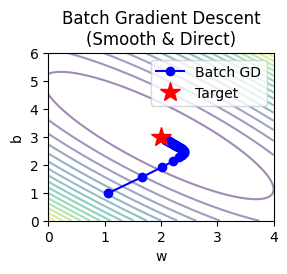

In [10]:
# 1. Batch GD
plt.subplot(2, 2, 1)
plt.contour(W, B, Loss_surf, levels=20, cmap='viridis', alpha=0.5)
plt.plot(batch_history['w'], batch_history['b'], 'o-', color='blue', label='Batch GD')
plt.plot(2, 3, 'r*', markersize=15, label='Target')
plt.title('Batch Gradient Descent\n(Smooth & Direct)')
plt.xlabel('w'); plt.ylabel('b')
plt.legend()

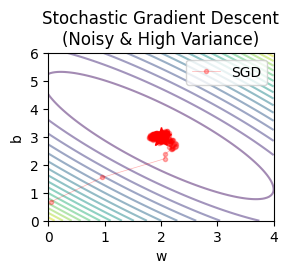

In [11]:

# 2. SGD
plt.subplot(2, 2, 2)
plt.contour(W, B, Loss_surf, levels=20, cmap='viridis', alpha=0.5)
plt.plot(sgd_history['w'], sgd_history['b'], '.-', color='red', alpha=0.3, linewidth=0.5, label='SGD')
plt.plot(2, 3, 'r*', markersize=15)
plt.title('Stochastic Gradient Descent\n(Noisy & High Variance)')
plt.xlabel('w'); plt.ylabel('b')
plt.legend()

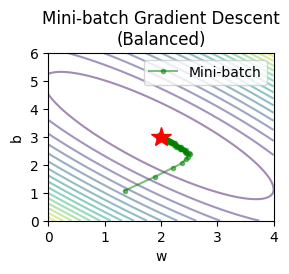

In [12]:
# 3. Mini-batch
plt.subplot(2, 2, 3)
plt.contour(W, B, Loss_surf, levels=20, cmap='viridis', alpha=0.5)
plt.plot(mini_history['w'], mini_history['b'], '.-', color='green', alpha=0.5, label='Mini-batch')
plt.plot(2, 3, 'r*', markersize=15)
plt.title('Mini-batch Gradient Descent\n(Balanced)')
plt.xlabel('w'); plt.ylabel('b')
plt.legend()

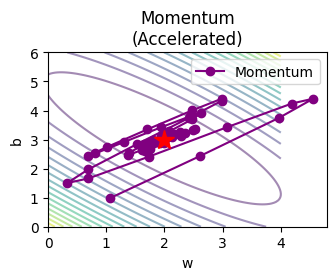

In [13]:
# 4. Momentum
plt.subplot(2, 2, 4)
plt.contour(W, B, Loss_surf, levels=20, cmap='viridis', alpha=0.5)
plt.plot(mom_history['w'], mom_history['b'], 'o-', color='purple', label='Momentum')
plt.plot(2, 3, 'r*', markersize=15)
plt.title('Momentum\n(Accelerated)')
plt.xlabel('w'); plt.ylabel('b')
plt.legend()

plt.tight_layout()
plt.show()

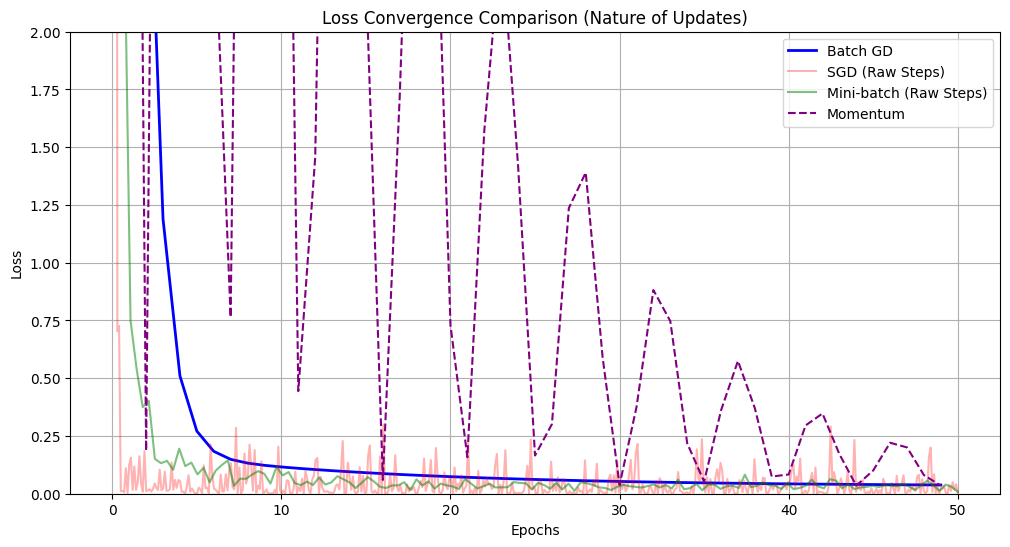

: 

In [ ]:
# --- Loss Comparison ---
plt.figure(figsize=(12, 6))
plt.plot(batch_history['loss'], label='Batch GD', linewidth=2, color='blue')
# Scaling x-axis for SGD and Mini-batch to match 'Epochs' roughly for visualization
plt.plot(np.linspace(0, len(batch_history['loss']), len(sgd_history['loss'])), sgd_history['loss'], alpha=0.3, color='red', label='SGD')
plt.plot(np.linspace(0, len(batch_history['loss']), len(mini_history['loss'])), mini_history['loss'], alpha=0.5, color='green', label='Mini-batch')
plt.plot(mom_history['loss'], label='Momentum', linestyle='--', color='purple')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Convergence Comparison (Nature of Updates)')
plt.ylim(0, 2) # Zoom in to see the noise near convergence
plt.legend()
plt.grid(True)
plt.show()

### Observations
1.  **Batch GD**: Takes a direct, smooth path but steps can be slow.
2.  **SGD**: Very noisy path, jumps around a lot. It eventually hovers around the minimum.
3.  **Mini-batch**: Less noisy than SGD, more stable.
4.  **Momentum**: Accelerates in the direction of the gradient, potentially overshooting slightly but converging faster in shallow valleys.

## TEST?

Try to change the code, inputs and observe the nature of Optimization algorithms we have selected.